## BIBLIOTECAS

In [1]:
import os
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configuração visual
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid', palette='muted')

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


## CONSTANTES GLOBAIS

In [2]:
# Constantes globais
SEED_ALEATORIA = 42
CAMINHO_DADOS = "data/table16.csv"
COLUNA_TARGET = 'TOTAL (R$)'
COLUNA_CATEGORIA = 'TIPO DA CONTA'
NIVEL_CONFIANCA = 0.95

# Variáveis globais para os datasets
df = None
df_clean = None
df_amostra = None

print("Constantes definidas com sucesso!")

Constantes definidas com sucesso!


## Classificação das Colunas

In [3]:
# Classificação estatística de cada coluna do dataset
CLASSIFICACAO_COLUNAS = {
    'NOTA FISCAL': 'Identificador (será removido)',
    'REGIÃO': 'Qualitativa Nominal',
    'SEXO': 'Qualitativa Nominal',
    'ESTADO CIVIL': 'Qualitativa Nominal',
    'DEPENDENTES': 'Quantitativa Discreta',
    'RENDA BRUTO (R$)': 'Quantitativa Contínua',
    'OPINIÃO DO CLIENTE': 'Qualitativa Nominal (texto livre)',
    'NOTA DE SATISFAÇÃO (%)': 'Quantitativa Contínua',
    'MEAN: alcohol': 'Quantitativa Contínua',
    'MEAN: malic_acid': 'Quantitativa Contínua',
    'MEAN: ash': 'Quantitativa Contínua',
    'MEAN: alcalinity_of_ash': 'Quantitativa Contínua',
    'MEAN: magnesium': 'Quantitativa Contínua',
    'MEAN: total_phenols': 'Quantitativa Contínua',
    'MEAN: flavanoids': 'Quantitativa Contínua',
    'MEAN: nonflavanoid_phenols': 'Quantitativa Contínua',
    'MEAN: proanthocyanins': 'Quantitativa Contínua',
    'MEAN: color_intensity': 'Quantitativa Contínua',
    'MEAN: hue': 'Quantitativa Contínua',
    'MEAN: od280/od315_of_diluted_wines': 'Quantitativa Contínua',
    'MEAN: proline': 'Quantitativa Contínua',
    'TIPO DA CONTA': 'Qualitativa Ordinal',
    'TOTAL (R$)': 'Quantitativa Contínua (TARGET y)'
}

# Variáveis qualitativas e quantitativas
COLUNAS_QUALITATIVAS = ['REGIÃO', 'SEXO', 'ESTADO CIVIL', 'TIPO DA CONTA']

COLUNAS_QUANTITATIVAS_X = [
    'DEPENDENTES',
    'RENDA BRUTO (R$)',
    'NOTA DE SATISFAÇÃO (%)',
    'MEAN: alcohol',
    'MEAN: malic_acid',
    'MEAN: ash',
    'MEAN: alcalinity_of_ash',
    'MEAN: magnesium',
    'MEAN: total_phenols',
    'MEAN: flavanoids',
    'MEAN: nonflavanoid_phenols',
    'MEAN: proanthocyanins',
    'MEAN: color_intensity',
    'MEAN: hue',
    'MEAN: od280/od315_of_diluted_wines',
    'MEAN: proline',
]

COLUNAS_IRRELEVANTES = ['NOTA FISCAL', 'OPINIÃO DO CLIENTE']

print("Classificações definidas com sucesso!")

Classificações definidas com sucesso!


---
# ETAPA 1: ETL - Extract, Transform and Load

## Atividade 1 (A1): Pesquisar (load) o dataset

In [4]:
def Atividade1_1() -> pd.DataFrame:
    """
    Carrega o dataset table16.csv utilizando pandas.
    O arquivo possui mais de 1 milhão de linhas e é lido completo na memória.
    A primeira coluna (índice) é usada como index do DataFrame.
    
    Returns:
        pd.DataFrame: DataFrame com os dados carregados.
    """
    global df
    df = pd.read_csv(CAMINHO_DADOS, index_col=0)
    print(f"Dataset carregado com sucesso!")
    print(f"Dimensões: {df.shape[0]:,} linhas x {df.shape[1]} colunas\n")
    print("Primeiras 3 linhas:")
    return df

# Executar
df = Atividade1_1()
df.head(3)

Dataset carregado com sucesso!
Dimensões: 1,120,000 linhas x 23 colunas

Primeiras 3 linhas:


,NOTA FISCAL,REGIÃO,SEXO,ESTADO CIVIL,DEPENDENTES,RENDA BRUTO (R$),OPINIÃO DO CLIENTE,NOTA DE SATISFAÇÃO (%),MEAN: alcohol,MEAN: malic_acid,...,MEAN: total_phenols,MEAN: flavanoids,MEAN: nonflavanoid_phenols,MEAN: proanthocyanins,MEAN: color_intensity,MEAN: hue,MEAN: od280/od315_of_diluted_wines,MEAN: proline,TIPO DA CONTA,TOTAL (R$)
0,6876333,SUL,MASCULINO,SOLTEIRO,1,3336.84,"Serviço eficiente, recomendo o clube: UVVine",68.68,12.929435,2.447630,...,1.334842,2.236478,0.290384,1.661732,7.833947,0.952735,3.818190,276.681180,ESSENTIAL,302.31
1,5677339,SUDESTE,MASCULINO,CASADO,2,3453.34,"Serviço eficiente, recomendo o clube: UVVine",68.68,13.993214,1.393874,...,1.475983,1.676041,0.385297,1.940256,2.139143,0.910653,3.042307,377.891615,ESSENTIAL,278.26
2,1104271,SUDESTE,FEMININO,SOLTEIRO,1,3211.29,"Serviço impecável, adorei o clube: UVVine",68.68,11.161985,3.471322,...,0.820464,2.363073,0.264392,1.617888,4.953122,1.120121,3.019603,709.736181,ESSENTIAL,580.02


## Atividade 2 (A2): Descrição / Classificação de todas as colunas

In [5]:
def Atividade1_2() -> pd.DataFrame:
    """
    Exibe a descrição e classificação estatística de todas as colunas do dataset.
    Classifica cada variável em: Qualitativa Nominal, Qualitativa Ordinal,
    Quantitativa Discreta ou Quantitativa Contínua.
    
    Returns:
        pd.DataFrame: Tabela descritiva com a classificação de cada coluna.
    """
    global df
    tabela = pd.DataFrame({
        'Tipo Pandas': df.dtypes.values,
        'Classificacao Estatistica': [
            CLASSIFICACAO_COLUNAS.get(col, '-') for col in df.columns
        ],
        'Valores Unicos': [df[col].nunique() for col in df.columns],
        'Valores Nulos': [df[col].isnull().sum() for col in df.columns],
        'Exemplo': [str(df[col].iloc[0]) for col in df.columns],
    }, index=df.columns)
    
    print("=" * 90)
    print("DESCRIÇÃO E CLASSIFICAÇÃO DAS COLUNAS")
    print("=" * 90)
    return tabela

# Executar
tabela_colunas = Atividade1_2()
tabela_colunas

DESCRIÇÃO E CLASSIFICAÇÃO DAS COLUNAS


,Tipo Pandas,Classificacao Estatistica,Valores Unicos,Valores Nulos,Exemplo
NOTA FISCAL,int64,Identificador (será removido),1120000,0,6876333
REGIÃO,str,Qualitativa Nominal,5,0,SUL
SEXO,str,Qualitativa Nominal,2,0,MASCULINO
ESTADO CIVIL,str,Qualitativa Nominal,3,0,SOLTEIRO
DEPENDENTES,int64,Quantitativa Discreta,5,0,1
RENDA BRUTO (R$),float64,Quantitativa Contínua,388538,0,3336.84
OPINIÃO DO CLIENTE,str,Qualitativa Nominal (texto livre),25,0,"Serviço eficiente, recomendo o clube: UVVine"
NOTA DE SATISFAÇÃO (%),float64,Quantitativa Contínua,204,0,68.68
MEAN: alcohol,float64,Quantitativa Contínua,1120000,0,12.929434550908864
MEAN: malic_acid,float64,Quantitativa Contínua,1120000,0,2.4476297109142444


---
# ETAPA 2: Data Exploration

## Atividade (A1): Definir / Eliminar colunas NÃO relevantes

In [6]:
def Atividade2_1() -> pd.DataFrame:
    """
    Define e elimina as colunas não relevantes ao projeto.
    Colunas removidas:
    - NOTA FISCAL: identificador único sem valor preditivo ou estatístico.
    - OPINIÃO DO CLIENTE: texto livre não estruturado para análise estatística.
    
    Returns:
        pd.DataFrame: Dataset sem as colunas irrelevantes.
    """
    global df, df_clean
    print(f"Colunas no dataset original: {df.shape[1]}")
    print(f"Removendo colunas: {COLUNAS_IRRELEVANTES}\n")
    
    df_clean = df.drop(columns=COLUNAS_IRRELEVANTES)
    
    print(f"Colunas após remoção ({df_clean.shape[1]}):")
    for col in df_clean.columns:
        print(f" - {col}")
    
    return df_clean

# Executar
df_clean = Atividade2_1()

Colunas no dataset original: 23
Removendo colunas: ['NOTA FISCAL', 'OPINIÃO DO CLIENTE']

Colunas após remoção (21):
 - REGIÃO
 - SEXO
 - ESTADO CIVIL
 - DEPENDENTES
 - RENDA BRUTO (R$)
 - NOTA DE SATISFAÇÃO (%)
 - MEAN: alcohol
 - MEAN: malic_acid
 - MEAN: ash
 - MEAN: alcalinity_of_ash
 - MEAN: magnesium
 - MEAN: total_phenols
 - MEAN: flavanoids
 - MEAN: nonflavanoid_phenols
 - MEAN: proanthocyanins
 - MEAN: color_intensity
 - MEAN: hue
 - MEAN: od280/od315_of_diluted_wines
 - MEAN: proline
 - TIPO DA CONTA
 - TOTAL (R$)


## Atividade (A2): Pesquisar / Eliminar duplicatas e valores nulos

In [7]:
def Atividade2_2() -> pd.DataFrame:
    """
    Pesquisa e elimina valores duplicados (linhas duplicadas) e
    valores sentinela (NaN: NotANumber) do dataset.
    
    Returns:
        pd.DataFrame: Dataset sem duplicatas e sem valores nulos.
    """
    global df_clean
    total_inicial = len(df_clean)
    
    # SEÇÃO 1 — Valores Duplicados
    num_duplicatas = df_clean.duplicated().sum()
    print(f"Linhas duplicadas encontradas: {num_duplicatas:,}")
    
    if num_duplicatas > 0:
        df_clean = df_clean.drop_duplicates()
        print(f" -> {num_duplicatas:,} linhas duplicadas removidas.\n")
    else:
        print(" -> Nenhuma linha duplicada encontrada.\n")
    
    # SEÇÃO 2 — Valores Nulos (NaN)
    nulos = df_clean.isnull().sum()
    total_nulos = nulos.sum()
    print(f"Valores nulos (NaN) encontrados: {total_nulos:,}")
    
    if total_nulos > 0:
        print("Distribuição por coluna:")
        print(nulos[nulos > 0].to_string())
        df_clean = df_clean.dropna()
        print(" -> Linhas com NaN removidas.")
    else:
        print(" -> Nenhum valor nulo encontrado.")
    
    total_final = len(df_clean)
    print(f"\nResumo da limpeza:")
    print(f" Antes: {total_inicial:,} linhas")
    print(f" Depois: {total_final:,} linhas")
    print(f" Removidas: {total_inicial - total_final:,} linhas")
    
    return df_clean

# Executar
df_clean = Atividade2_2()

Linhas duplicadas encontradas: 0
 -> Nenhuma linha duplicada encontrada.

Valores nulos (NaN) encontrados: 0
 -> Nenhum valor nulo encontrado.

Resumo da limpeza:
 Antes: 1,120,000 linhas
 Depois: 1,120,000 linhas
 Removidas: 0 linhas


## Atividade (A3): Pesquisar / Eliminar Outliers da Variável y (TARGET)

Análise de Outliers — TOTAL (R$)
 Q1: R$       319.99
 Q3: R$     1,026.27
 IQR: R$       706.28
 Limite inferior: R$      -739.43
 Limite superior: R$     2,085.69

 Outliers: 110,160 (9.84%)


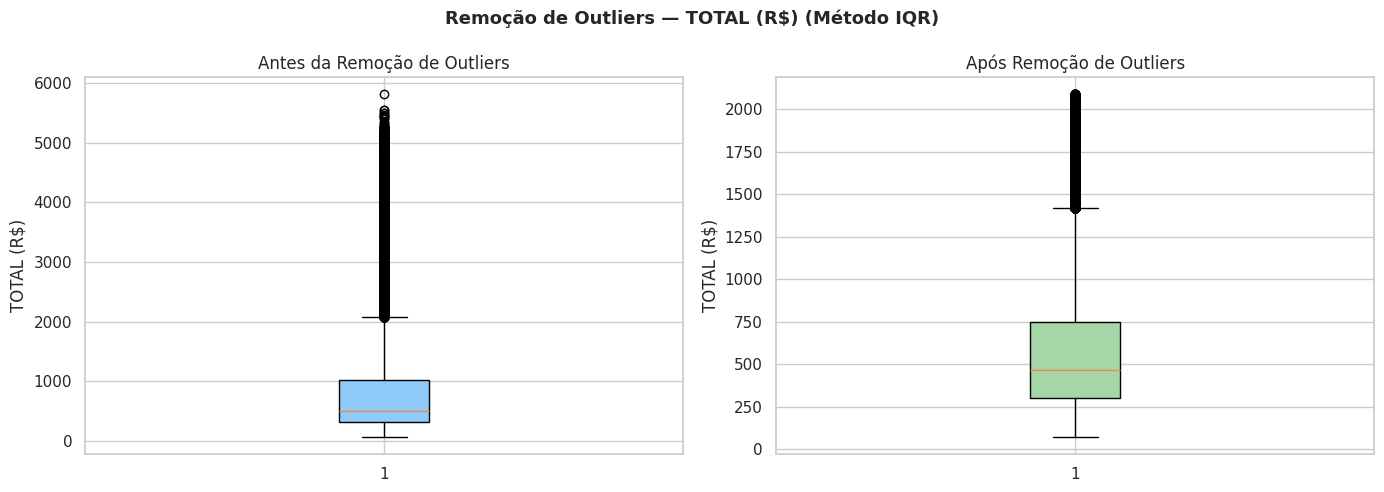


Linhas antes: 1,120,000
Linhas após: 1,009,840
Removidas: 110,160


In [8]:
def Atividade2_3() -> pd.DataFrame:
    """
    Pesquisa e elimina outliers da variável target y (TOTAL R$)
    usando o método IQR (Intervalo Interquartil).
    Critério: valores fora de [Q1 - 1.5*IQR, Q3 + 1.5*IQR] são outliers.
    
    Returns:
        pd.DataFrame: Dataset sem outliers na variável target.
    """
    global df_clean
    total_inicial = len(df_clean)
    
    # Cálculo do IQR
    q1 = df_clean[COLUNA_TARGET].quantile(0.25)
    q3 = df_clean[COLUNA_TARGET].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    
    mascara_outliers = (
        (df_clean[COLUNA_TARGET] < limite_inferior) |
        (df_clean[COLUNA_TARGET] > limite_superior)
    )
    
    num_outliers = mascara_outliers.sum()
    print(f"Análise de Outliers — {COLUNA_TARGET}")
    print(f" Q1: R$ {q1:>12,.2f}")
    print(f" Q3: R$ {q3:>12,.2f}")
    print(f" IQR: R$ {iqr:>12,.2f}")
    print(f" Limite inferior: R$ {limite_inferior:>12,.2f}")
    print(f" Limite superior: R$ {limite_superior:>12,.2f}")
    print(f"\n Outliers: {num_outliers:,} ({num_outliers / total_inicial * 100:.2f}%)")
    
    # Visualização: boxplot antes e depois
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].boxplot(df_clean[COLUNA_TARGET], vert=True, patch_artist=True,
                    boxprops=dict(facecolor='#90CAF9'))
    axes[0].set_title('Antes da Remoção de Outliers')
    axes[0].set_ylabel('TOTAL (R$)')
    
    df_clean = df_clean[~mascara_outliers].reset_index(drop=True)
    
    axes[1].boxplot(df_clean[COLUNA_TARGET], vert=True, patch_artist=True,
                    boxprops=dict(facecolor='#A5D6A7'))
    axes[1].set_title('Após Remoção de Outliers')
    axes[1].set_ylabel('TOTAL (R$)')
    
    plt.suptitle(f'Remoção de Outliers — {COLUNA_TARGET} (Método IQR)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    total_final = len(df_clean)
    print(f"\nLinhas antes: {total_inicial:,}")
    print(f"Linhas após: {total_final:,}")
    print(f"Removidas: {total_inicial - total_final:,}")
    
    return df_clean

# Executar
df_clean = Atividade2_3()

---
# ETAPA 3: Data Evaluation

## ETAPA 3.0: Análise Bootstrap para Determinação do Tamanho Ideal da Amostra

In [9]:
# Constantes para Bootstrap
N_BOOTSTRAP = 1000
LIMIAR_REDUCAO_EP = 0.05
TAMANHOS_AMOSTRA = [50, 100, 250, 500, 1000, 2000, 5000, 10000]

def calcular_bootstrap(dados: np.ndarray, n_amostra: int, n_iteracoes: int, seed: int) -> dict:
    """
    Calcula estatísticas bootstrap por amostragem com reposição.
    Usa amostragem vetorizada para maior performance.
    
    Args:
        dados: Array numpy com os valores da variável.
        n_amostra: Tamanho de cada amostra bootstrap.
        n_iteracoes: Número de iterações.
        seed: Semente aleatória para reprodutibilidade.
    
    Returns:
        dict com: media, erro_padrao, ic_inferior, ic_superior.
    """
    rng = np.random.default_rng(seed)
    n_efetivo = min(n_amostra, len(dados))
    
    # Amostragem vetorizada
    indices = rng.integers(0, len(dados), size=(n_iteracoes, n_efetivo))
    medias = dados[indices].mean(axis=1)
    
    alpha = 1.0 - NIVEL_CONFIANCA
    return {
        'media': float(medias.mean()),
        'erro_padrao': float(medias.std(ddof=1)),
        'ic_inferior': float(np.percentile(medias, 100 * alpha / 2)),
        'ic_superior': float(np.percentile(medias, 100 * (1 - alpha / 2))),
    }

# Dados separados por categoria
dados_por_categoria = {
    'ESSENTIAL': df_clean[df_clean[COLUNA_CATEGORIA] == 'ESSENTIAL'][COLUNA_TARGET].values,
    'VIP': df_clean[df_clean[COLUNA_CATEGORIA] == 'VIP'][COLUNA_TARGET].values,
    'PRIME': df_clean[df_clean[COLUNA_CATEGORIA] == 'PRIME'][COLUNA_TARGET].values,
    'GERAL': df_clean[COLUNA_TARGET].values,
}

# Cálculo do erro padrão para cada tamanho de amostra
resultados_ep = {cat: [] for cat in dados_por_categoria}
print("Calculando bootstrap... aguarde.")

for categoria, dados in dados_por_categoria.items():
    for n in TAMANHOS_AMOSTRA:
        res = calcular_bootstrap(dados, n, N_BOOTSTRAP, SEED_ALEATORIA)
        resultados_ep[categoria].append(res['erro_padrao'])
    print(f" '{categoria}' concluído.")

print("Bootstrap concluído!")

Calculando bootstrap... aguarde.
 'ESSENTIAL' concluído.
 'VIP' concluído.
 'PRIME' concluído.
 'GERAL' concluído.
Bootstrap concluído!


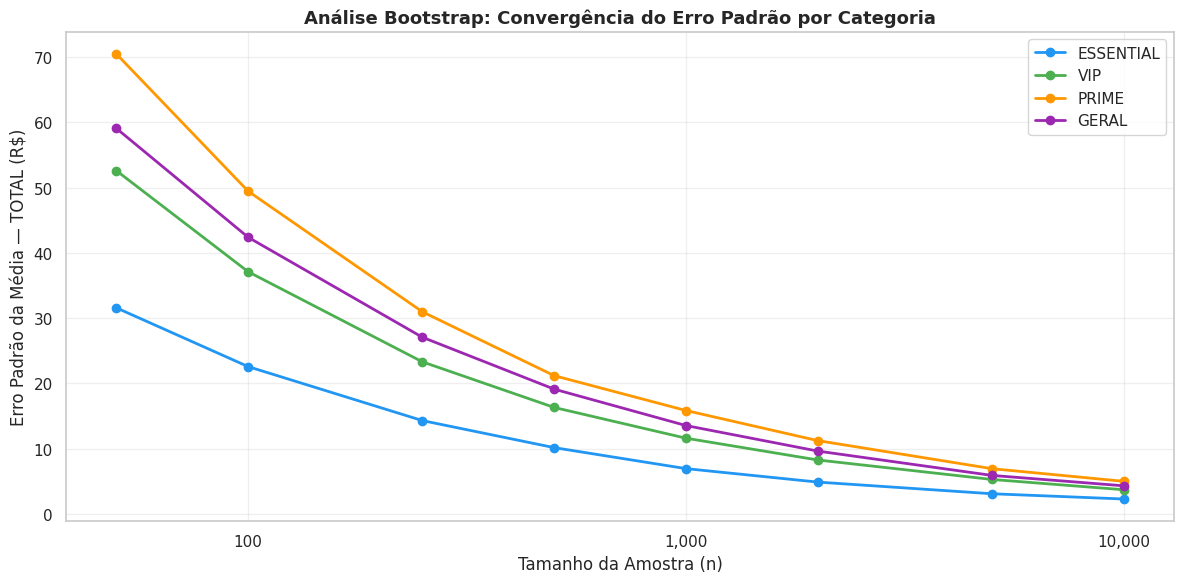

In [10]:
# GRÁFICO — Convergência do Erro Padrão da Média
fig, ax = plt.subplots(figsize=(12, 6))
cores_cat = {'ESSENTIAL': '#2196F3', 'VIP': '#4CAF50', 'PRIME': '#FF9800'}

for categoria in dados_por_categoria:
    ax.plot(
        TAMANHOS_AMOSTRA, resultados_ep[categoria],
        marker='o', label=categoria,
        color=cores_cat.get(categoria, '#9C27B0'), linewidth=2, markersize=6
    )

ax.set_xlabel('Tamanho da Amostra (n)', fontsize=12)
ax.set_ylabel('Erro Padrão da Média — TOTAL (R$)', fontsize=12)
ax.set_title('Análise Bootstrap: Convergência do Erro Padrão por Categoria',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xscale('log')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

In [11]:
# DETERMINAÇÃO DO TAMANHO IDEAL DA AMOSTRA
print("\n" + "=" * 72)
print("DETERMINAÇÃO DO TAMANHO IDEAL DA AMOSTRA")
print(f"Critério: redução relativa do EP < {LIMIAR_REDUCAO_EP*100:.0f}% entre tamanhos")
print("=" * 72)

tamanho_ideal_por_categoria = {}
for categoria in dados_por_categoria:
    ep_lista = resultados_ep[categoria]
    tamanho_ideal = TAMANHOS_AMOSTRA[-1]
    
    for i in range(1, len(TAMANHOS_AMOSTRA)):
        if ep_lista[i - 1] > 0:
            reducao = (ep_lista[i - 1] - ep_lista[i]) / ep_lista[i - 1]
            if reducao < LIMIAR_REDUCAO_EP:
                tamanho_ideal = TAMANHOS_AMOSTRA[i - 1]
                break
    
    tamanho_ideal_por_categoria[categoria] = tamanho_ideal

# Tabela de resultados
print(f"\n{'Categoria':<12} {'n ideal':>10} {'Média':>14} {'EP':>12} {'IC 95% Inf':>14} {'IC 95% Sup':>14}")
print("-" * 82)

for categoria, dados in dados_por_categoria.items():
    n_ideal = tamanho_ideal_por_categoria[categoria]
    res = calcular_bootstrap(dados, n_ideal, N_BOOTSTRAP, SEED_ALEATORIA)
    print(
        f"{categoria:<12} {n_ideal:>10,} "
        f"R${res['media']:>10,.2f} "
        f"R${res['erro_padrao']:>8,.2f} "
        f"R${res['ic_inferior']:>10,.2f} "
        f"R${res['ic_superior']:>10,.2f}"
    )

# Criar amostra ideal
TAMANHO_IDEAL = tamanho_ideal_por_categoria['GERAL']
df_amostra = df_clean.sample(n=TAMANHO_IDEAL, random_state=SEED_ALEATORIA)

print(f"\nAmostra ideal criada: {len(df_amostra):,} registros (tamanho ideal GERAL)")
print(f"Distribuição por tipo de conta:")
print(df_amostra[COLUNA_CATEGORIA].value_counts().to_string())


DETERMINAÇÃO DO TAMANHO IDEAL DA AMOSTRA
Critério: redução relativa do EP < 5% entre tamanhos

Categoria       n ideal          Média           EP     IC 95% Inf     IC 95% Sup
----------------------------------------------------------------------------------
ESSENTIAL        10,000 R$    390.78 R$    2.26 R$    386.37 R$    395.29
VIP              10,000 R$    870.29 R$    3.68 R$    863.05 R$    877.22
PRIME            10,000 R$  1,259.95 R$    4.97 R$  1,250.07 R$  1,269.45
GERAL            10,000 R$    594.66 R$    4.29 R$    586.11 R$    602.92

Amostra ideal criada: 10,000 registros (tamanho ideal GERAL)
Distribuição por tipo de conta:
TIPO DA CONTA
ESSENTIAL    6483
VIP          2542
PRIME         975


## ETAPA 3.1: Análise exploratória das Variáveis Qualitativas

### Atividade (A1): Gráficos de Pareto

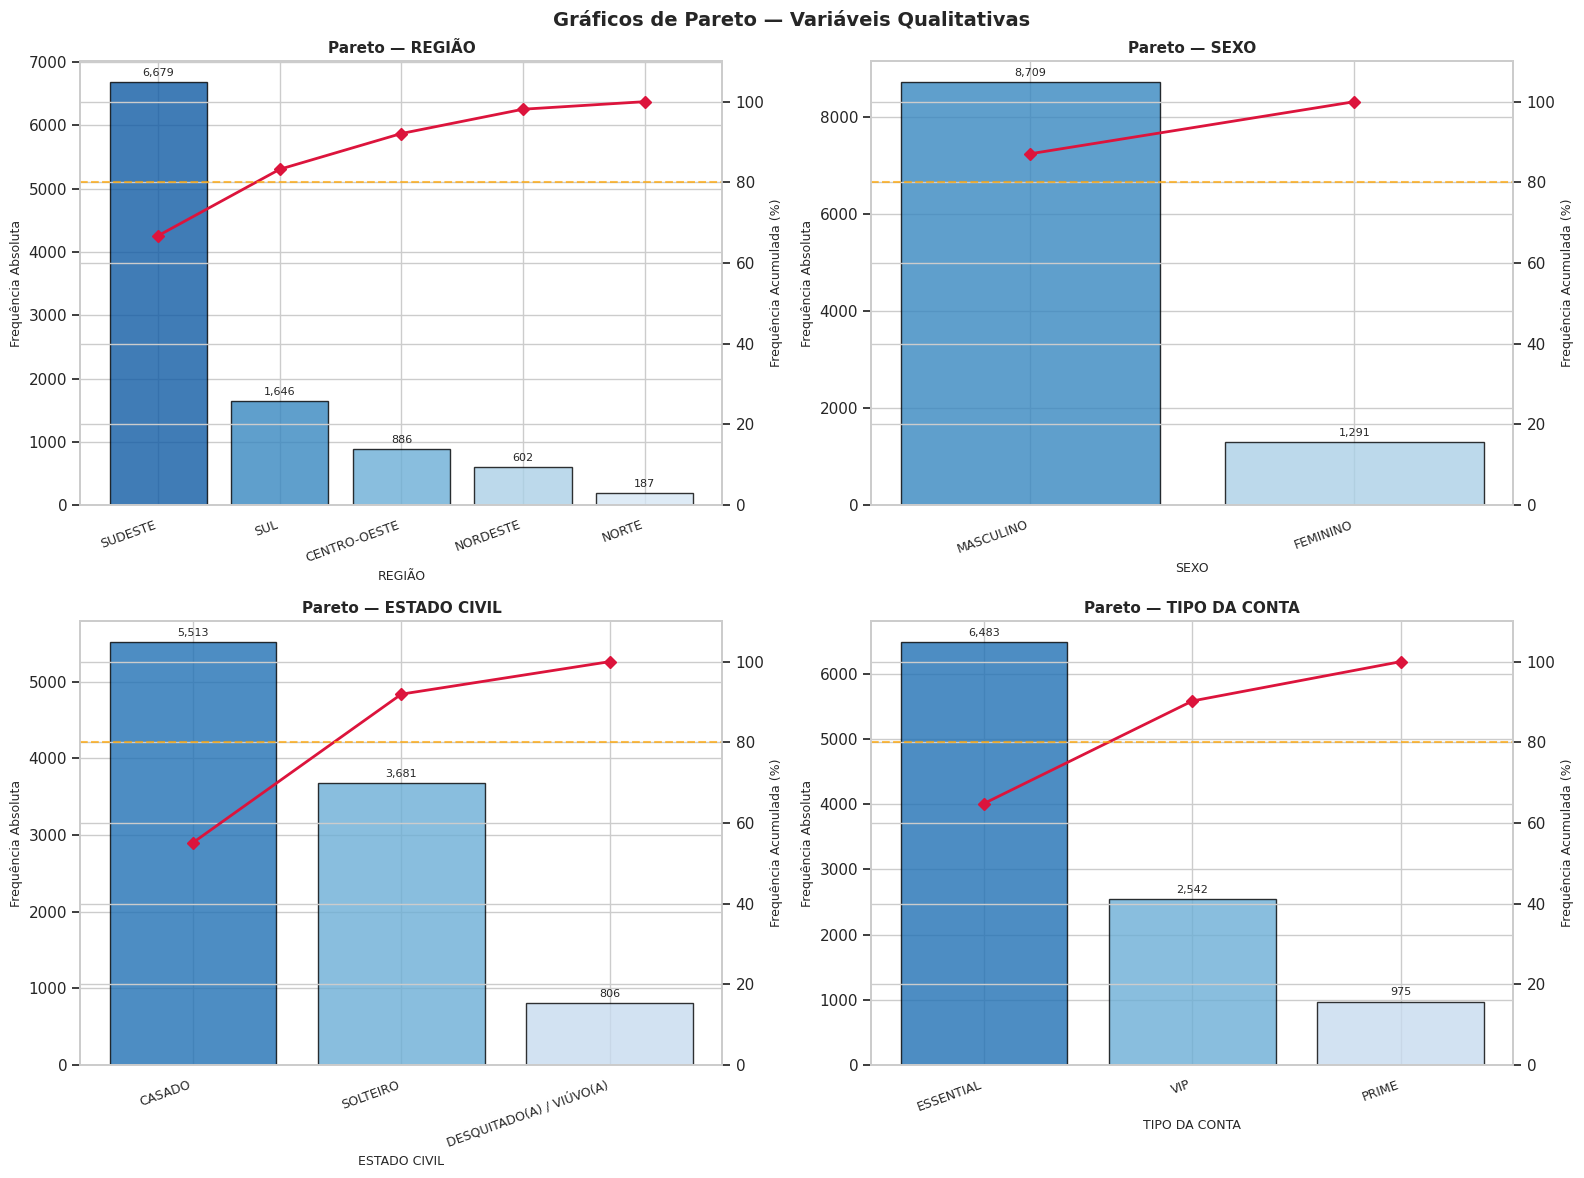

In [12]:
def Atividade3_1_1() -> None:
    """
    Cria o gráfico de Pareto para cada variável qualitativa do dataset.
    O gráfico de Pareto exibe as frequências absolutas em ordem decrescente
    e a frequência acumulada relativa (%) como curva sobreposta.
    A linha tracejada em 80% indica o limiar do princípio de Pareto.
    """
    global df_amostra
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()
    
    for idx, coluna in enumerate(COLUNAS_QUALITATIVAS):
        ax1 = axes[idx]
        ax2 = ax1.twinx()
        
        # Contagem ordenada por frequência decrescente
        contagem = df_amostra[coluna].value_counts().sort_values(ascending=False)
        categorias_col = contagem.index.tolist()
        frequencias = contagem.values
        freq_acumulada = np.cumsum(frequencias) / frequencias.sum() * 100
        
        # Barras com paleta de azuis
        cores = sns.color_palette("Blues_r", len(categorias_col))
        barras = ax1.bar(categorias_col, frequencias, color=cores, edgecolor='black', alpha=0.8)
        
        # Linha de frequência acumulada
        ax2.plot(categorias_col, freq_acumulada, color='crimson',
                marker='D', linewidth=2, markersize=6, label='Freq. Acumulada')
        ax2.axhline(y=80, color='orange', linestyle='--', linewidth=1.5, alpha=0.7)
        ax2.set_ylim(0, 110)
        ax2.set_ylabel('Frequência Acumulada (%)', fontsize=9)
        
        # Rótulos nas barras
        for barra, freq in zip(barras, frequencias):
            ax1.text(
                barra.get_x() + barra.get_width() / 2,
                barra.get_height() + max(frequencias) * 0.01,
                f'{freq:,}', ha='center', va='bottom', fontsize=8
            )
        
        ax1.set_title(f'Pareto — {coluna}', fontsize=11, fontweight='bold')
        ax1.set_xlabel(coluna, fontsize=9)
        ax1.set_ylabel('Frequência Absoluta', fontsize=9)
        plt.setp(ax1.get_xticklabels(), rotation=20, ha='right', fontsize=9)
    
    plt.suptitle('Gráficos de Pareto — Variáveis Qualitativas', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Executar
Atividade3_1_1()

### Atividade (A2): Tabulação Cruzada

In [13]:
def Atividade3_1_2() -> None:
    """
    Cria tabelas de tabulação cruzada (crosstab) para cada variável qualitativa
    cruzada com a variável TIPO DA CONTA.
    Exibe valores absolutos (contagens) e relativos (% por linha).
    """
    global df_amostra
    
    colunas_para_cruzar = ['REGIÃO', 'SEXO', 'ESTADO CIVIL']
    
    for coluna in colunas_para_cruzar:
        print("=" * 65)
        print(f"Tabulação Cruzada: {coluna} x TIPO DA CONTA")
        print("=" * 65)
        
        # Valores absolutos com totais marginais
        tab_absoluta = pd.crosstab(
            df_amostra[coluna],
            df_amostra[COLUNA_CATEGORIA],
            margins=True,
            margins_name='TOTAL'
        )
        
        # Valores relativos por linha (%)
        tab_relativa = (
            pd.crosstab(
                df_amostra[coluna],
                df_amostra[COLUNA_CATEGORIA],
                normalize='index'
            ) * 100
        ).round(1).astype(str) + '%'
        
        print("\nFrequências Absolutas:")
        print(tab_absoluta)
        
        print("\nFrequências Relativas (% por linha):")
        print(tab_relativa)
        print()

# Executar
Atividade3_1_2()

Tabulação Cruzada: REGIÃO x TIPO DA CONTA

Frequências Absolutas:
TIPO DA CONTA  ESSENTIAL  PRIME   VIP  TOTAL
REGIÃO                                      
CENTRO-OESTE         574     76   236    886
NORDESTE             365     58   179    602
NORTE                121     17    49    187
SUDESTE             4327    664  1688   6679
SUL                 1096    160   390   1646
TOTAL               6483    975  2542  10000

Frequências Relativas (% por linha):
TIPO DA CONTA ESSENTIAL PRIME    VIP
REGIÃO                              
CENTRO-OESTE      64.8%  8.6%  26.6%
NORDESTE          60.6%  9.6%  29.7%
NORTE             64.7%  9.1%  26.2%
SUDESTE           64.8%  9.9%  25.3%
SUL               66.6%  9.7%  23.7%

Tabulação Cruzada: SEXO x TIPO DA CONTA

Frequências Absolutas:
TIPO DA CONTA  ESSENTIAL  PRIME   VIP  TOTAL
SEXO                                        
FEMININO             862    114   315   1291
MASCULINO           5621    861  2227   8709
TOTAL               6483    975 

## ETAPA 3.2: Análise exploratória das Variáveis Quantitativas

### Atividade (A1): Estatística Descritiva das Variáveis de Entrada (X)

ESTATÍSTICA DESCRITIVA — VARIÁVEIS QUANTITATIVAS DE ENTRADA (X)
                                          n      media  desvio_padrao  \
DEPENDENTES                         10000.0     1.0670         0.9588   
RENDA BRUTO (R$)                    10000.0  6048.7065      4979.1939   
NOTA DE SATISFAÇÃO (%)              10000.0    68.8011         0.8733   
MEAN: alcohol                       10000.0    12.9911         0.8066   
MEAN: malic_acid                    10000.0     2.3175         1.1162   
MEAN: ash                           10000.0     2.3653         0.2748   
MEAN: alcalinity_of_ash             10000.0    19.5496         3.3526   
MEAN: magnesium                     10000.0    99.8436        14.5101   
MEAN: total_phenols                 10000.0     2.3062         0.6099   
MEAN: flavanoids                    10000.0     2.0206         0.9929   
MEAN: nonflavanoid_phenols          10000.0     0.3615         0.1241   
MEAN: proanthocyanins               10000.0     1.6012      

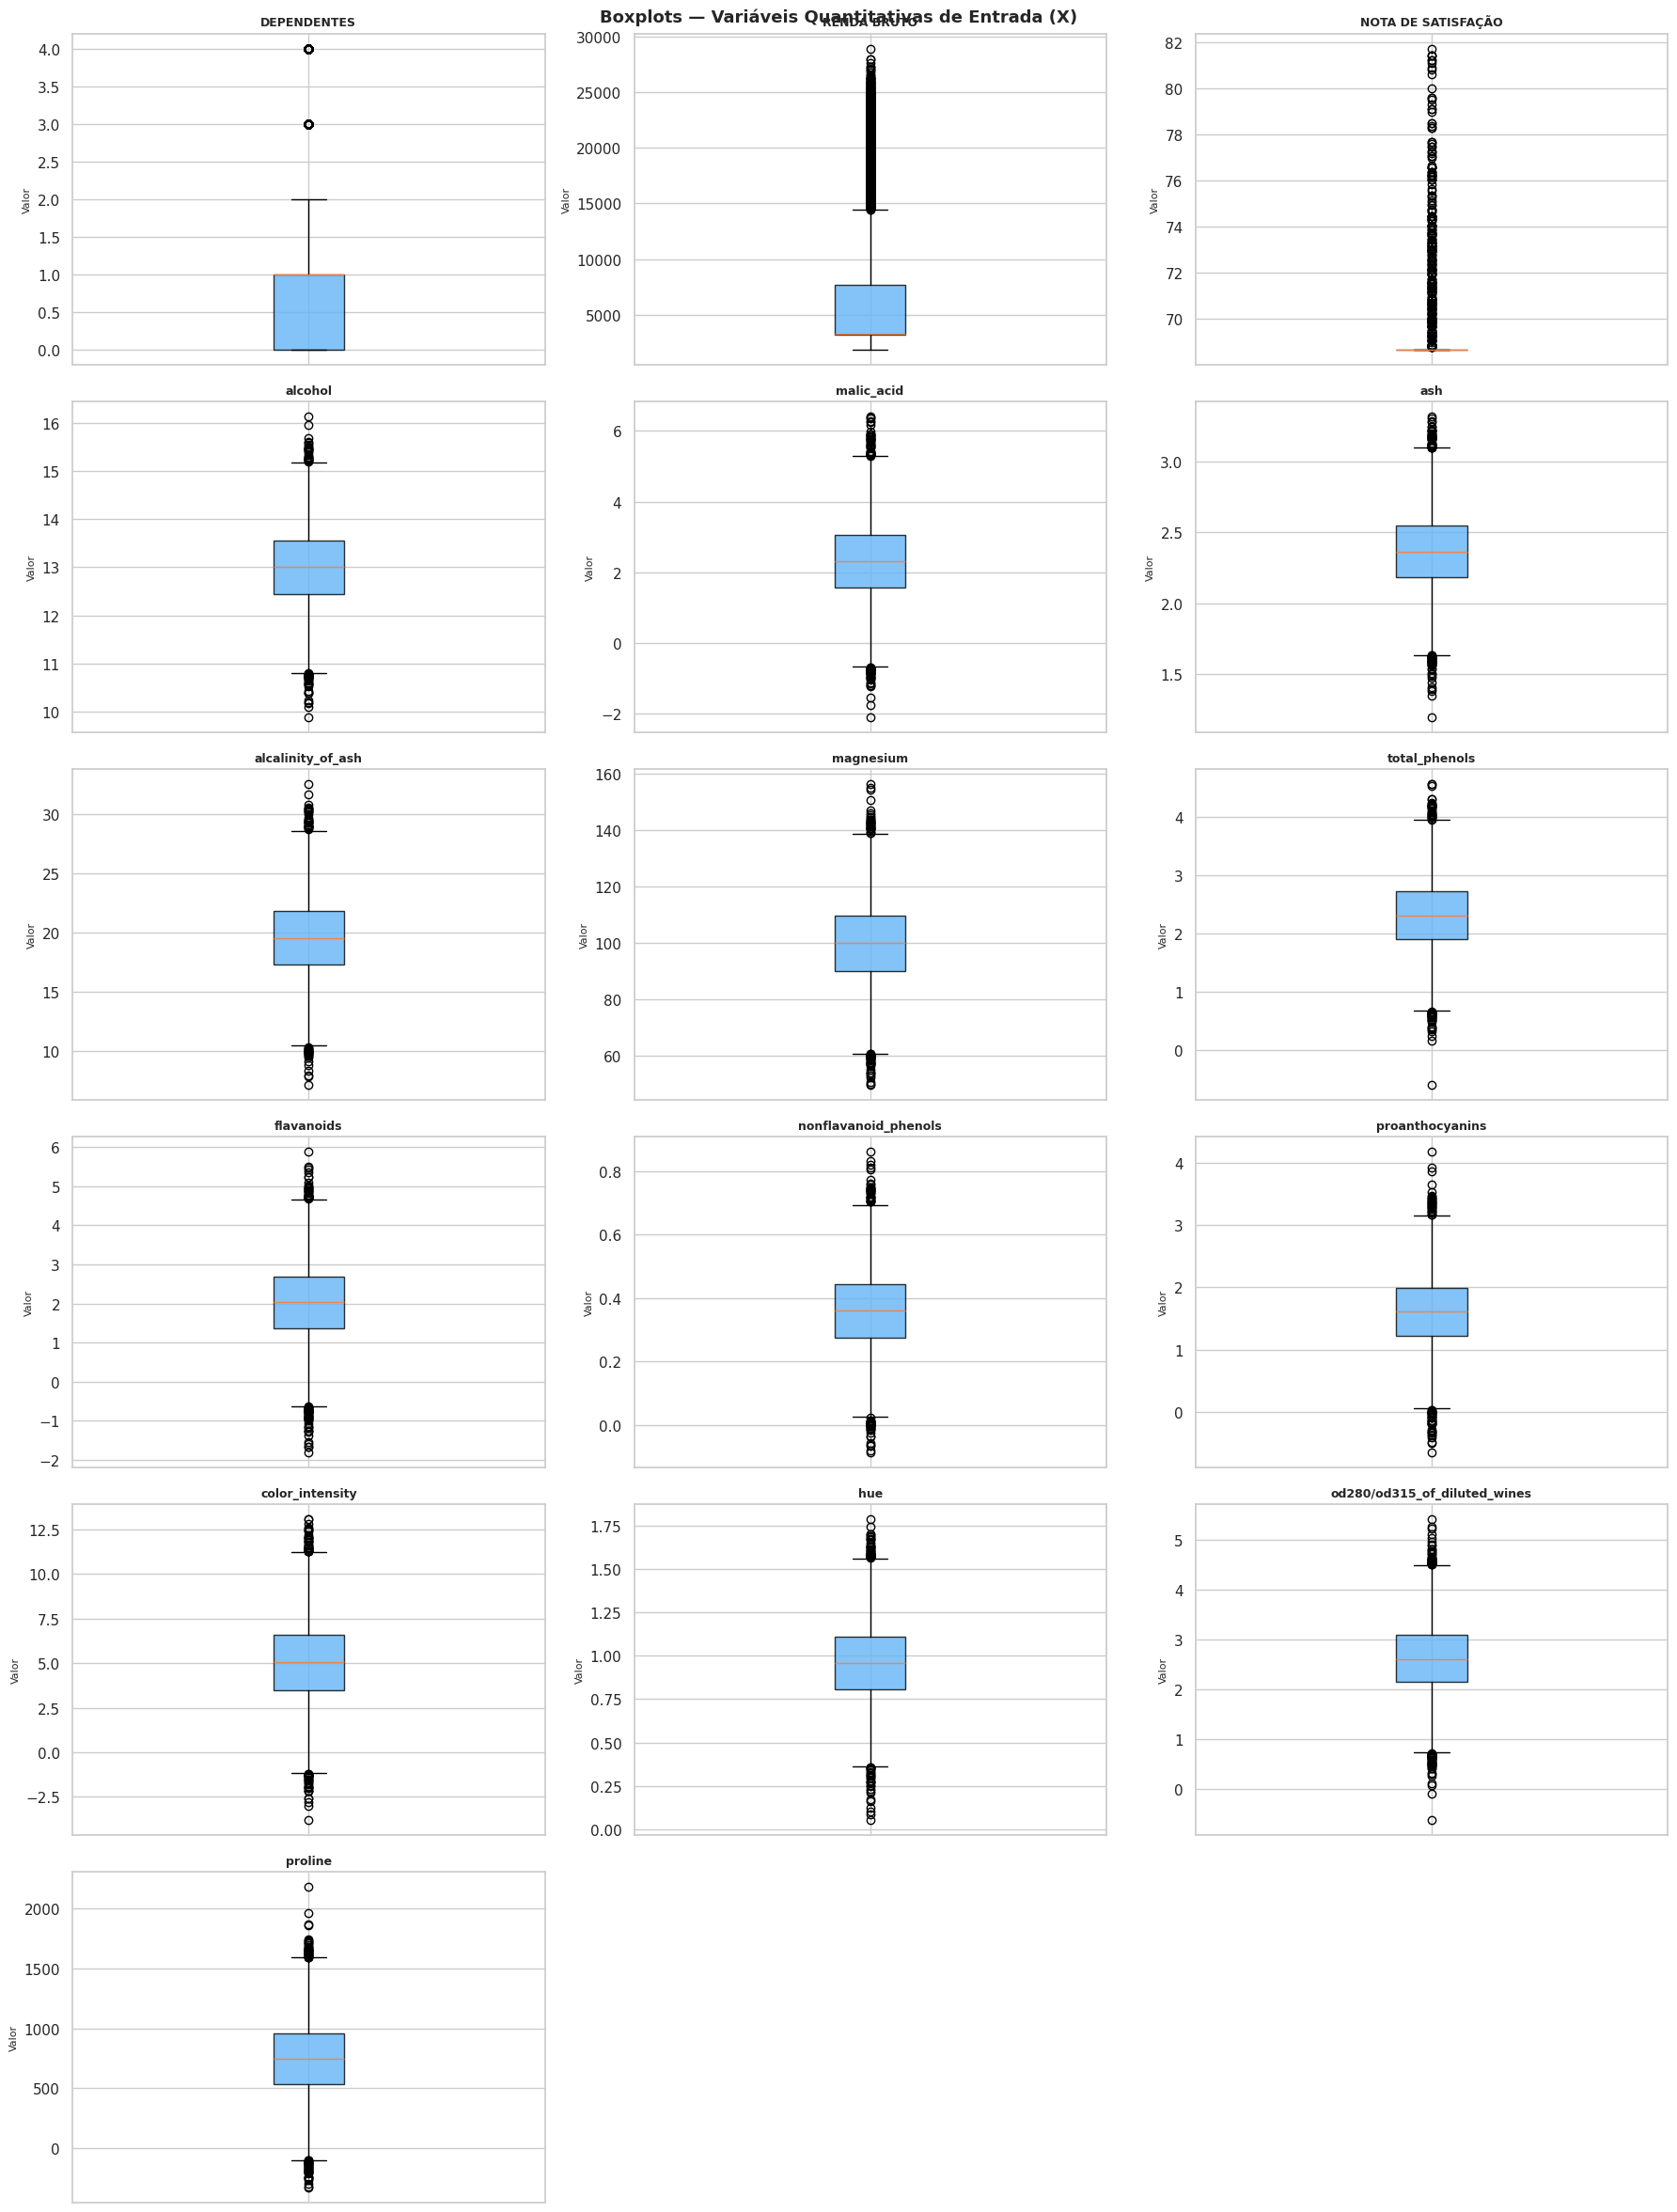

In [14]:
def Atividade3_2_1() -> pd.DataFrame:
    """
    Gera relatório com estatística descritiva de cada variável quantitativa.
    Exibe boxplots de cada variável para visualização da dispersão.
    
    Returns:
        pd.DataFrame: Tabela de estatísticas descritivas das variáveis X.
    """
    global df_amostra
    
    descritivas = df_amostra[COLUNAS_QUANTITATIVAS_X].describe().T.round(4)
    descritivas.columns = ['n', 'media', 'desvio_padrao', 'min', 'Q1', 'mediana', 'Q3', 'max']
    
    print("=" * 80)
    print("ESTATÍSTICA DESCRITIVA — VARIÁVEIS QUANTITATIVAS DE ENTRADA (X)")
    print("=" * 80)
    print(descritivas)
    
    # Boxplots para visualização da dispersão
    n_vars = len(COLUNAS_QUANTITATIVAS_X)
    n_cols = 3
    n_rows = (n_vars + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
    axes = axes.flatten()
    
    for idx, coluna in enumerate(COLUNAS_QUANTITATIVAS_X):
        ax = axes[idx]
        ax.boxplot(
            df_amostra[coluna].dropna(), vert=True, patch_artist=True,
            boxprops=dict(facecolor='#64B5F6', alpha=0.8)
        )
        nome_curto = coluna.replace('MEAN: ', '').replace(' (R$)', '').replace(' (%)', '')
        ax.set_title(nome_curto, fontsize=9, fontweight='bold')
        ax.set_ylabel('Valor', fontsize=8)
        ax.tick_params(axis='x', labelbottom=False)
    
    for idx in range(n_vars, len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle('Boxplots — Variáveis Quantitativas de Entrada (X)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return descritivas

# Executar
descritivas_x = Atividade3_2_1()

### Atividade (A2): Estatística Descritiva do Target (y)

ESTATÍSTICA DESCRITIVA — TARGET: TOTAL (R$)
                 n    media  desvio_padrao     min      Q1  mediana       Q3  \
GERAL      10000.0   590.60         419.67   81.59  299.10   461.81   730.32   
ESSENTIAL   6483.0   385.03         208.70  102.12  236.87   365.04   492.35   
PRIME        975.0  1267.50         484.22   92.31  930.78  1288.44  1653.02   
VIP         2542.0   855.26         371.97   81.59  543.52   837.20  1159.15   

               max  
GERAL      2084.22  
ESSENTIAL  2035.81  
PRIME      2084.22  
VIP        2065.69  


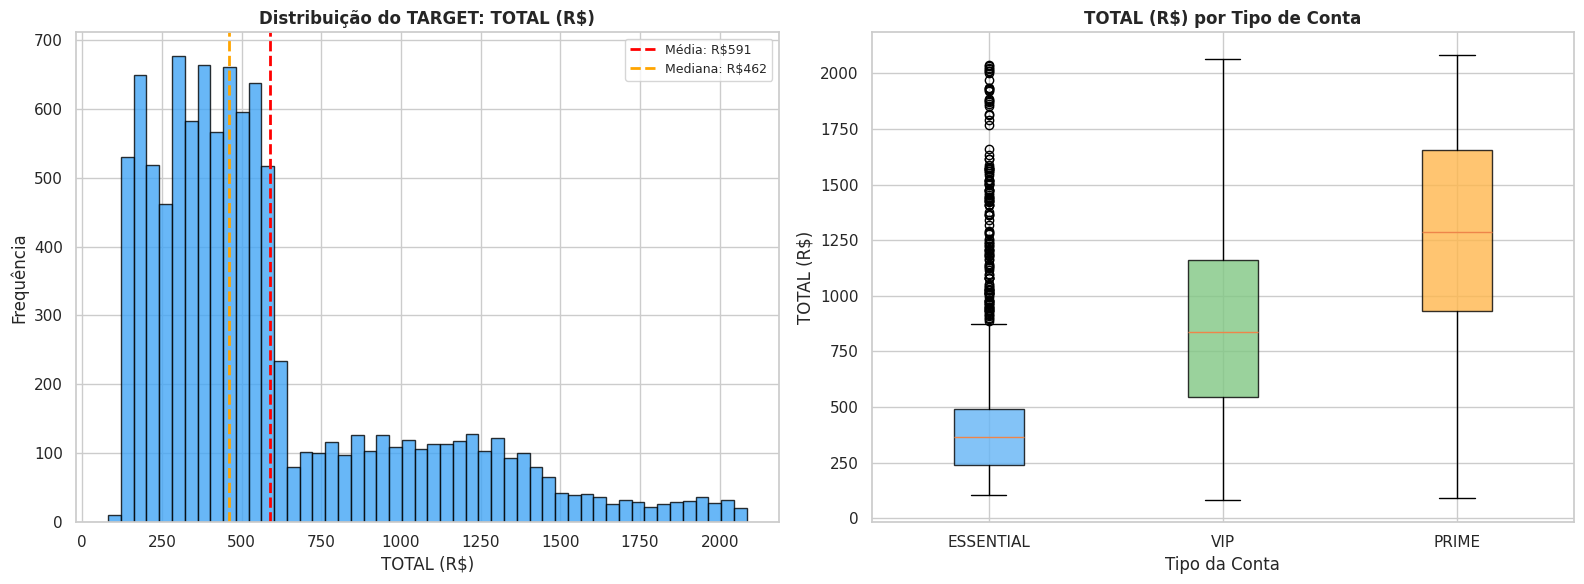

In [15]:
def Atividade3_2_2() -> pd.DataFrame:
    """
    Gera relatório com estatística descritiva da variável target y (TOTAL R$).
    Inclui estatísticas gerais e desagregadas por categoria de TIPO DA CONTA.
    Exibe histograma e boxplot por categoria.
    
    Returns:
        pd.DataFrame: Tabela de estatísticas descritivas do target.
    """
    global df_amostra
    
    print("=" * 70)
    print(f"ESTATÍSTICA DESCRITIVA — TARGET: {COLUNA_TARGET}")
    print("=" * 70)
    
    # Estatísticas gerais
    stats_geral = df_amostra[COLUNA_TARGET].describe().to_frame().T
    stats_geral.index = ['GERAL']
    
    # Estatísticas por categoria de TIPO DA CONTA
    stats_cat = df_amostra.groupby(COLUNA_CATEGORIA)[COLUNA_TARGET].describe()
    
    tabela = pd.concat([stats_geral, stats_cat])
    tabela.columns = ['n', 'media', 'desvio_padrao', 'min', 'Q1', 'mediana', 'Q3', 'max']
    tabela = tabela.round(2)
    
    print(tabela)
    
    # Visualização: histograma + boxplot por categoria
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Histograma com indicação de média e mediana
    ax = axes[0]
    ax.hist(df_amostra[COLUNA_TARGET], bins=50, color='#42A5F5', edgecolor='black', alpha=0.8)
    ax.axvline(df_amostra[COLUNA_TARGET].mean(), color='red', linestyle='--', linewidth=2,
              label=f"Média: R${df_amostra[COLUNA_TARGET].mean():,.0f}")
    ax.axvline(df_amostra[COLUNA_TARGET].median(), color='orange', linestyle='--', linewidth=2,
              label=f"Mediana: R${df_amostra[COLUNA_TARGET].median():,.0f}")
    ax.set_title('Distribuição do TARGET: TOTAL (R$)', fontsize=12, fontweight='bold')
    ax.set_xlabel('TOTAL (R$)')
    ax.set_ylabel('Frequência')
    ax.legend(fontsize=9)
    
    # Boxplot por tipo de conta
    ax = axes[1]
    ordem_cats = [c for c in ['ESSENTIAL', 'VIP', 'PRIME']
                  if c in df_amostra[COLUNA_CATEGORIA].unique()]
    dados_box = [df_amostra[df_amostra[COLUNA_CATEGORIA] == cat][COLUNA_TARGET].values
                for cat in ordem_cats]
    cores_box = ['#64B5F6', '#81C784', '#FFB74D']
    
    bp = ax.boxplot(dados_box, tick_labels=ordem_cats, patch_artist=True)
    for patch, cor in zip(bp['boxes'], cores_box):
        patch.set_facecolor(cor)
        patch.set_alpha(0.8)
    
    ax.set_title('TOTAL (R$) por Tipo de Conta', fontsize=12, fontweight='bold')
    ax.set_xlabel('Tipo da Conta')
    ax.set_ylabel('TOTAL (R$)')
    
    plt.tight_layout()
    plt.show()
    
    return tabela

# Executar
descritivas_y = Atividade3_2_2()

### Atividade (A3): Parâmetros de Forma da Variável y

PARÂMETROS DE FORMA — TOTAL (R$)
 Média: R$       590.60
 Mediana: R$       461.81
 Moda: R$       166.66

 Assimetria (Skew):   1.3986 -> Positiva (cauda para a direita)
 Curtose (Kurtosis):   1.3769 -> Leptocúrtica (caudas pesadas)


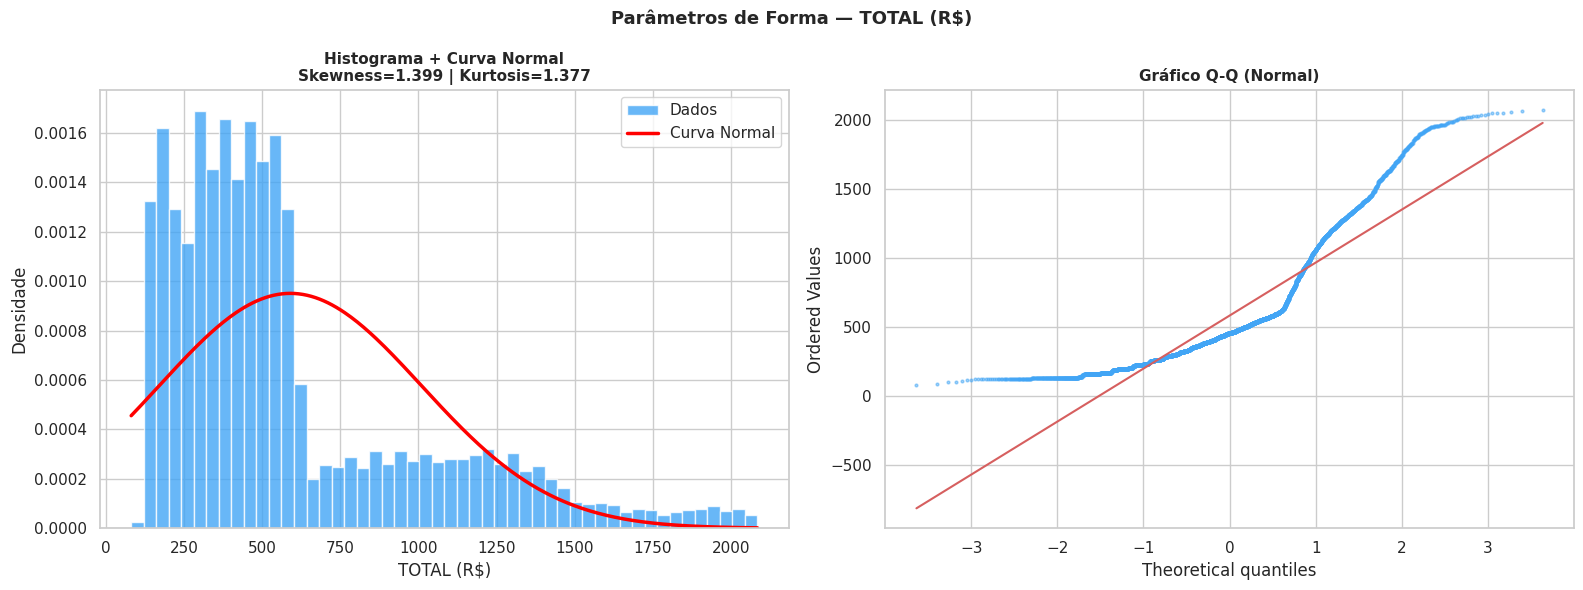

In [16]:
def Atividade3_2_3() -> None:
    """
    Analisa os parâmetros de forma da variável target y (TOTAL R$):
    - Assimetria (Skewness)
    - Curtose (Excess Kurtosis de Fisher)
    - Histograma com curva normal sobreposta
    - Gráfico Q-Q (Quantile-Quantile)
    """
    global df_amostra
    
    valores_y = df_amostra[COLUNA_TARGET]
    assimetria = valores_y.skew()
    curtose = valores_y.kurtosis()
    
    # Interpretação da assimetria
    if assimetria > 0.5:
        tipo_assimetria = "Positiva (cauda para a direita)"
    elif assimetria < -0.5:
        tipo_assimetria = "Negativa (cauda para a esquerda)"
    else:
        tipo_assimetria = "Simétrica (aprox. normal)"
    
    # Interpretação da curtose
    if curtose > 0.5:
        tipo_curtose = "Leptocúrtica (caudas pesadas)"
    elif curtose < -0.5:
        tipo_curtose = "Platicúrtica (caudas leves)"
    else:
        tipo_curtose = "Mesocúrtica (semelhante a normal)"
    
    print("=" * 60)
    print(f"PARÂMETROS DE FORMA — {COLUNA_TARGET}")
    print("=" * 60)
    print(f" Média: R$ {valores_y.mean():>12,.2f}")
    print(f" Mediana: R$ {valores_y.median():>12,.2f}")
    print(f" Moda: R$ {valores_y.mode().iloc[0]:>12,.2f}")
    print(f"\n Assimetria (Skew): {assimetria:>8.4f} -> {tipo_assimetria}")
    print(f" Curtose (Kurtosis): {curtose:>8.4f} -> {tipo_curtose}")
    
    # Gráficos
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Histograma com curva normal sobreposta
    ax = axes[0]
    ax.hist(valores_y, bins=50, density=True, color='#42A5F5',
           edgecolor='white', alpha=0.8, label='Dados')
    
    mu, sigma = valores_y.mean(), valores_y.std()
    x_norm = np.linspace(valores_y.min(), valores_y.max(), 300)
    ax.plot(x_norm, stats.norm.pdf(x_norm, mu, sigma), color='red', linewidth=2.5,
           label='Curva Normal')
    
    ax.set_title(f'Histograma + Curva Normal\nSkewness={assimetria:.3f} | Kurtosis={curtose:.3f}',
                fontsize=11, fontweight='bold')
    ax.set_xlabel('TOTAL (R$)')
    ax.set_ylabel('Densidade')
    ax.legend()
    
    # Q-Q plot
    ax = axes[1]
    amostra_qq = valores_y.sample(min(5000, len(valores_y)), random_state=SEED_ALEATORIA)
    stats.probplot(amostra_qq, dist='norm', plot=ax)
    ax.set_title('Gráfico Q-Q (Normal)', fontsize=11, fontweight='bold')
    ax.get_lines()[0].set(markersize=2, alpha=0.5, color='#42A5F5')
    
    plt.suptitle(f'Parâmetros de Forma — {COLUNA_TARGET}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Executar
Atividade3_2_3()

## ETAPA 3.3: Aplicação e Análise por Métodos Quantitativos

### Atividade (A1): Testes de Hipótese - Normalidade

In [17]:
def Atividade3_3_1() -> None:
    """
    Realiza testes de hipótese de normalidade para o target y (TOTAL R$).

    Testes realizados:
    - Shapiro-Wilk: preciso para amostras pequenas (limite: 5.000 obs.)
    - Kolmogorov-Smirnov: comparação com distribuição normal padronizada.

    H0: A distribuição é normal.
    H1: A distribuição NÃO é normal.
    Nível de significância: alpha = 5% (0.05).
    """
    global df_amostra

    ALPHA = 0.05
    N_MAX_SHAPIRO = 5000

    print('=' * 65)
    print(f"TESTES DE NORMALIDADE — {COLUNA_TARGET}")
    print(f"Nível de significância: alpha = {ALPHA} (5%)")
    print('=' * 65)

    # Amostra para os testes (Shapiro-Wilk limitado a 5000 obs.)
    n_teste = min(N_MAX_SHAPIRO, len(df_amostra))
    amostra = df_amostra[COLUNA_TARGET].sample(n_teste, random_state=SEED_ALEATORIA)

    # Teste Shapiro-Wilk
    stat_sw, p_sw = stats.shapiro(amostra)
    res_sw = "REJEITA H0 (não normal)" if p_sw < ALPHA else "NÃO REJEITA H0"
    print(f"\n1. Shapiro-Wilk  (n={n_teste:,})")
    print(f"   Estatística W : {stat_sw:.6f}")
    print(f"   p-valor       : {p_sw:.6f}")
    print(f"   Resultado     : {res_sw}")

    # Teste Kolmogorov-Smirnov (dados padronizados)
    amostra_pad = (amostra - amostra.mean()) / amostra.std()
    stat_ks, p_ks = stats.kstest(amostra_pad, 'norm')
    res_ks = "REJEITA H0 (não normal)" if p_ks < ALPHA else "NÃO REJEITA H0"
    print(f"\n2. Kolmogorov-Smirnov")
    print(f"   Estatística D : {stat_ks:.6f}")
    print(f"   p-valor       : {p_ks:.6f}")
    print(f"   Resultado     : {res_ks}")

    # Análise por categoria de TIPO DA CONTA
    print(f"\n{'Categoria':<12} {'W':>10} {'p-valor (SW)':>14} {'Resultado':>30}")
    print('-' * 72)
    for cat in ['ESSENTIAL', 'VIP', 'PRIME']:
        dados_cat = df_amostra[df_amostra[COLUNA_CATEGORIA] == cat][COLUNA_TARGET]
        n_cat = min(N_MAX_SHAPIRO, len(dados_cat))
        amostra_cat = dados_cat.sample(n_cat, random_state=SEED_ALEATORIA)
        w, p = stats.shapiro(amostra_cat)
        res = "REJEITA H0" if p < ALPHA else "NÃO REJEITA H0"
        print(f"{cat:<12} {w:>10.6f} {p:>14.6f} {res:>30}")


# Executar
Atividade3_3_1()


TESTES DE NORMALIDADE — TOTAL (R$)
Nível de significância: alpha = 0.05 (5%)

1. Shapiro-Wilk  (n=5,000)
   Estatística W : 0.841095
   p-valor       : 0.000000
   Resultado     : REJEITA H0 (não normal)

2. Kolmogorov-Smirnov
   Estatística D : 0.197218
   p-valor       : 0.000000
   Resultado     : REJEITA H0 (não normal)

Categoria             W   p-valor (SW)                      Resultado
------------------------------------------------------------------------
ESSENTIAL      0.783810       0.000000                     REJEITA H0
VIP            0.970594       0.000000                     REJEITA H0
PRIME          0.973401       0.000000                     REJEITA H0


### Atividade (A2): Testes de Dependência:

In [18]:
def Atividade3_3_2() -> None:
    """
    Realiza testes de dependência entre variáveis do dataset.

    Testes realizados:
    - Qui-Quadrado (chi2): independência entre variáveis qualitativas e TIPO DA CONTA.
    - Correlação de Spearman: associação entre variáveis quantitativas e TOTAL (R$).

    H0: As variáveis são independentes.
    H1: As variáveis são dependentes.
    Nível de significância: alpha = 5%.
    """
    global df_amostra

    ALPHA = 0.05

    # ============================================================
    # TESTE QUI-QUADRADO — qualitativas x TIPO DA CONTA
    # ============================================================
    print('=' * 72)
    print('TESTE QUI-QUADRADO — Variáveis qualitativas x TIPO DA CONTA')
    print(f"H0: As variáveis são independentes  |  alpha = {ALPHA}")
    print('=' * 72)

    colunas_qual = ['REGIÃO', 'SEXO', 'ESTADO CIVIL']
    print(f"\n{'Variável':<20} {'Chi2':>12} {'p-valor':>14} {'GL':>6} {'Resultado':>22}")
    print('-' * 78)

    for col in colunas_qual:
        tabela_ct = pd.crosstab(df_amostra[col], df_amostra[COLUNA_CATEGORIA])
        chi2, p, dof, _ = stats.chi2_contingency(tabela_ct)
        res = "DEPENDENTES" if p < ALPHA else "INDEPENDENTES"
        print(f"{col:<20} {chi2:>12.2f} {p:>14.6f} {dof:>6} {res:>22}")

    # ============================================================
    # CORRELAÇÃO DE SPEARMAN — quantitativas x TOTAL (R$)
    # ============================================================
    print(f"\n{'='*72}")
    print(f"CORRELAÇÃO DE SPEARMAN — Variáveis quantitativas x {COLUNA_TARGET}")
    print(f"{'='*72}")

    resultados_corr = {}
    for col in COLUNAS_QUANTITATIVAS_X:
        r, p = stats.spearmanr(df_amostra[col], df_amostra[COLUNA_TARGET])
        resultados_corr[col] = {
            'correlacao':   round(float(r), 4),
            'p_valor':      round(float(p), 6),
            'significativo': 'Sim' if p < ALPHA else 'Não'
        }

    df_corr = pd.DataFrame(resultados_corr).T
    df_corr = df_corr.sort_values('correlacao', key=abs, ascending=False)
    display(df_corr)


# Executar
Atividade3_3_2()


TESTE QUI-QUADRADO — Variáveis qualitativas x TIPO DA CONTA
H0: As variáveis são independentes  |  alpha = 0.05

Variável                     Chi2        p-valor     GL              Resultado
------------------------------------------------------------------------------
REGIÃO                      10.97       0.203389      8          INDEPENDENTES
SEXO                         2.75       0.252406      2          INDEPENDENTES
ESTADO CIVIL                 3.16       0.531610      4          INDEPENDENTES

CORRELAÇÃO DE SPEARMAN — Variáveis quantitativas x TOTAL (R$)


,correlacao,p_valor,significativo
RENDA BRUTO (R$),0.6608,0.0,Sim
NOTA DE SATISFAÇÃO (%),0.2535,0.0,Sim
MEAN: magnesium,0.015,0.132649,Não
MEAN: alcohol,-0.0141,0.158362,Não
DEPENDENTES,0.0135,0.175784,Não
MEAN: total_phenols,0.0128,0.199712,Não
MEAN: nonflavanoid_phenols,-0.0121,0.226351,Não
MEAN: hue,-0.0119,0.235761,Não
MEAN: od280/od315_of_diluted_wines,-0.0079,0.429571,Não
MEAN: flavanoids,0.0077,0.443133,Não


### Atividade (A3): Testes de mesma Distribuição Estatística

In [19]:
def Atividade3_3_3() -> None:
    """
    Testa se as categorias de TIPO DA CONTA possuem a mesma distribuição
    estatística para a variável target TOTAL (R$).

    Testes realizados:
    - Kruskal-Wallis: alternativa não-paramétrica ao ANOVA (indicada pois
      os dados não seguem distribuição normal conforme Atividade3_3_1).
    - Mann-Whitney U: comparação par a par entre categorias.

    H0: As categorias possuem a mesma distribuição.
    H1: Pelo menos uma categoria tem distribuição diferente.
    """
    global df_amostra

    ALPHA = 0.05
    CATS = ['ESSENTIAL', 'VIP', 'PRIME']

    # Grupos por categoria
    grupos = {
        cat: df_amostra[df_amostra[COLUNA_CATEGORIA] == cat][COLUNA_TARGET].values
        for cat in CATS
    }

    # ============================================================
    # KRUSKAL-WALLIS (teste global)
    # ============================================================
    stat_kw, p_kw = stats.kruskal(*grupos.values())
    res_kw = "REJEITA H0" if p_kw < ALPHA else "NÃO REJEITA H0"

    print('=' * 60)
    print('TESTE DE KRUSKAL-WALLIS')
    print(f"H0: ESSENTIAL = VIP = PRIME  |  alpha = {ALPHA}")
    print('=' * 60)
    print(f"\n Estatística H : {stat_kw:.4f}")
    print(f" p-valor        : {p_kw:.6f}")
    print(f" Resultado      : {res_kw}")

    # ============================================================
    # MANN-WHITNEY U — comparações par a par
    # ============================================================
    print(f"\n{'='*60}")
    print('MANN-WHITNEY U — Comparações Par a Par')
    print(f"{'='*60}")

    pares = [('ESSENTIAL', 'VIP'), ('ESSENTIAL', 'PRIME'), ('VIP', 'PRIME')]
    for cat1, cat2 in pares:
        stat_mw, p_mw = stats.mannwhitneyu(
            grupos[cat1], grupos[cat2], alternative='two-sided'
        )
        res = "DISTRIBUIÇÕES DIFERENTES" if p_mw < ALPHA else "MESMA DISTRIBUIÇÃO"
        print(f"\n {cat1} vs {cat2}:")
        print(f"   U = {stat_mw:.2f},  p = {p_mw:.6f}  ->  {res}")


# Executar
Atividade3_3_3()


TESTE DE KRUSKAL-WALLIS
H0: ESSENTIAL = VIP = PRIME  |  alpha = 0.05

 Estatística H : 4326.0408
 p-valor        : 0.000000
 Resultado      : REJEITA H0

MANN-WHITNEY U — Comparações Par a Par

 ESSENTIAL vs VIP:
   U = 2102162.00,  p = 0.000000  ->  DISTRIBUIÇÕES DIFERENTES

 ESSENTIAL vs PRIME:
   U = 381438.00,  p = 0.000000  ->  DISTRIBUIÇÕES DIFERENTES

 VIP vs PRIME:
   U = 633299.00,  p = 0.000000  ->  DISTRIBUIÇÕES DIFERENTES


## ETAPA 3.4: Análise e Redução de Dimensionalidade

### Atividade (A1): Análise das Características (Features)

ANÁLISE DE FEATURES — MÉTRICAS E CORRELAÇÃO COM TARGET
                                        media  desvio_padrao  cv (%)  \
feature                                                                
RENDA BRUTO (R$)                    6048.7065      4979.1939   82.32   
NOTA DE SATISFAÇÃO (%)                68.8011         0.8733    1.27   
MEAN: total_phenols                    2.3062         0.6099   26.45   
MEAN: hue                              0.9570         0.2229   23.29   
MEAN: nonflavanoid_phenols             0.3615         0.1241   34.34   
MEAN: od280/od315_of_diluted_wines     2.6095         0.7045   27.00   
MEAN: alcohol                         12.9911         0.8066    6.21   
MEAN: alcalinity_of_ash               19.5496         3.3526   17.15   
MEAN: magnesium                       99.8436        14.5101   14.53   
MEAN: proline                        747.7744       315.7043   42.22   
MEAN: flavanoids                       2.0206         0.9929   49.14   
MEAN: ash

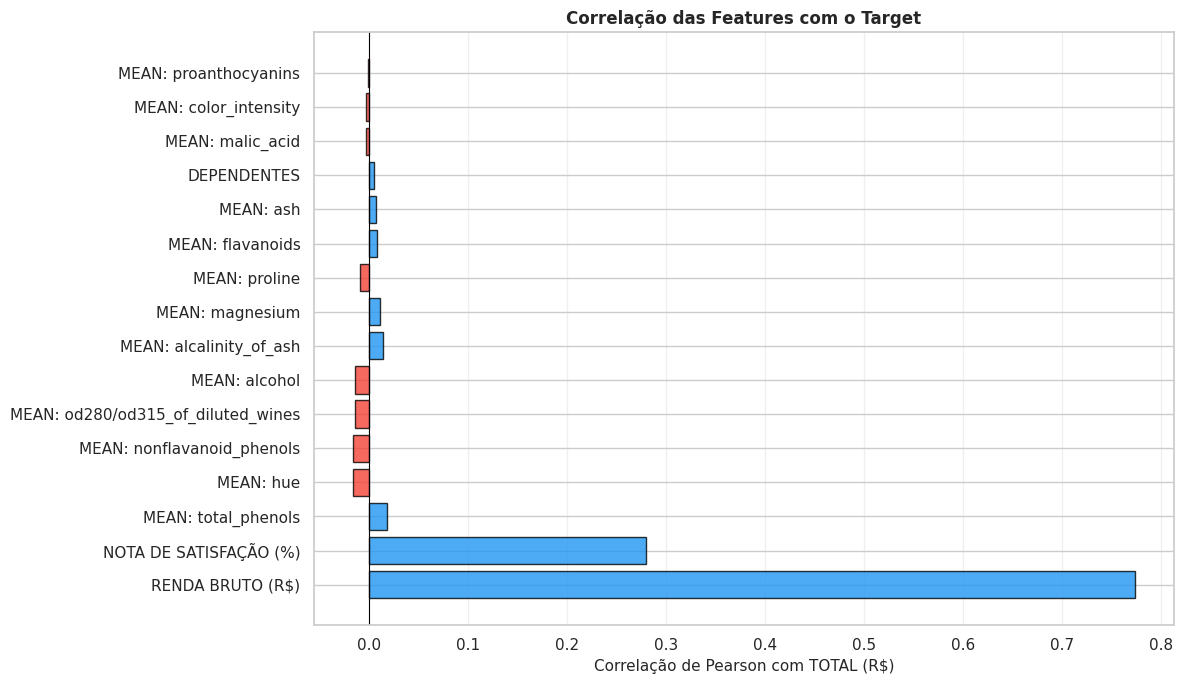

In [20]:
def Atividade3_4_1() -> pd.DataFrame:
    """
    Analisa as características (features) quantitativas do dataset.
    Metricas calculadas por feature:
    - Média e desvio padrão
    - Coeficiente de variação (CV): dispersão relativa
    - Correlação de Pearson com o target TOTAL (R$)
    - Correlação de Spearman com o target TOTAL (R$)
    
    Returns:
        pd.DataFrame: Tabela ordenada por relevância para o target.
    """
    global df_amostra
    
    metricas = []
    for col in COLUNAS_QUANTITATIVAS_X:
        serie = df_amostra[col].dropna()
        media = serie.mean()
        dp = serie.std()
        cv = abs(dp / media * 100) if media != 0 else 0
        
        r_pearson, _ = stats.pearsonr(df_amostra[col], df_amostra[COLUNA_TARGET])
        r_spearman, _ = stats.spearmanr(df_amostra[col], df_amostra[COLUNA_TARGET])
        
        metricas.append({
            'feature': col,
            'media': round(media, 4),
            'desvio_padrao': round(dp, 4),
            'cv (%)': round(cv, 2),
            'corr_pearson': round(float(r_pearson), 4),
            'corr_spearman': round(float(r_spearman), 4),
        })
    
    df_feat = (
        pd.DataFrame(metricas)
        .set_index('feature')
        .sort_values('corr_pearson', key=abs, ascending=False)
    )
    
    print("=" * 80)
    print("ANÁLISE DE FEATURES — MÉTRICAS E CORRELAÇÃO COM TARGET")
    print("=" * 80)
    print(df_feat)
    
    # Gráfico de correlação de Pearson com o target
    fig, ax = plt.subplots(figsize=(12, 7))
    cores = ['#F44336' if v < 0 else '#2196F3' for v in df_feat['corr_pearson']]
    ax.barh(df_feat.index, df_feat['corr_pearson'], color=cores, edgecolor='black', alpha=0.8)
    ax.axvline(x=0, color='black', linewidth=0.8)
    ax.set_xlabel('Correlação de Pearson com TOTAL (R$)', fontsize=11)
    ax.set_title('Correlação das Features com o Target', fontsize=12, fontweight='bold')
    ax.grid(True, axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return df_feat

# Executar
df_features = Atividade3_4_1()

### Atividade (A2): Análise das Correlações (Heatmaps)

Mapa de Correlações — ESSENTIAL


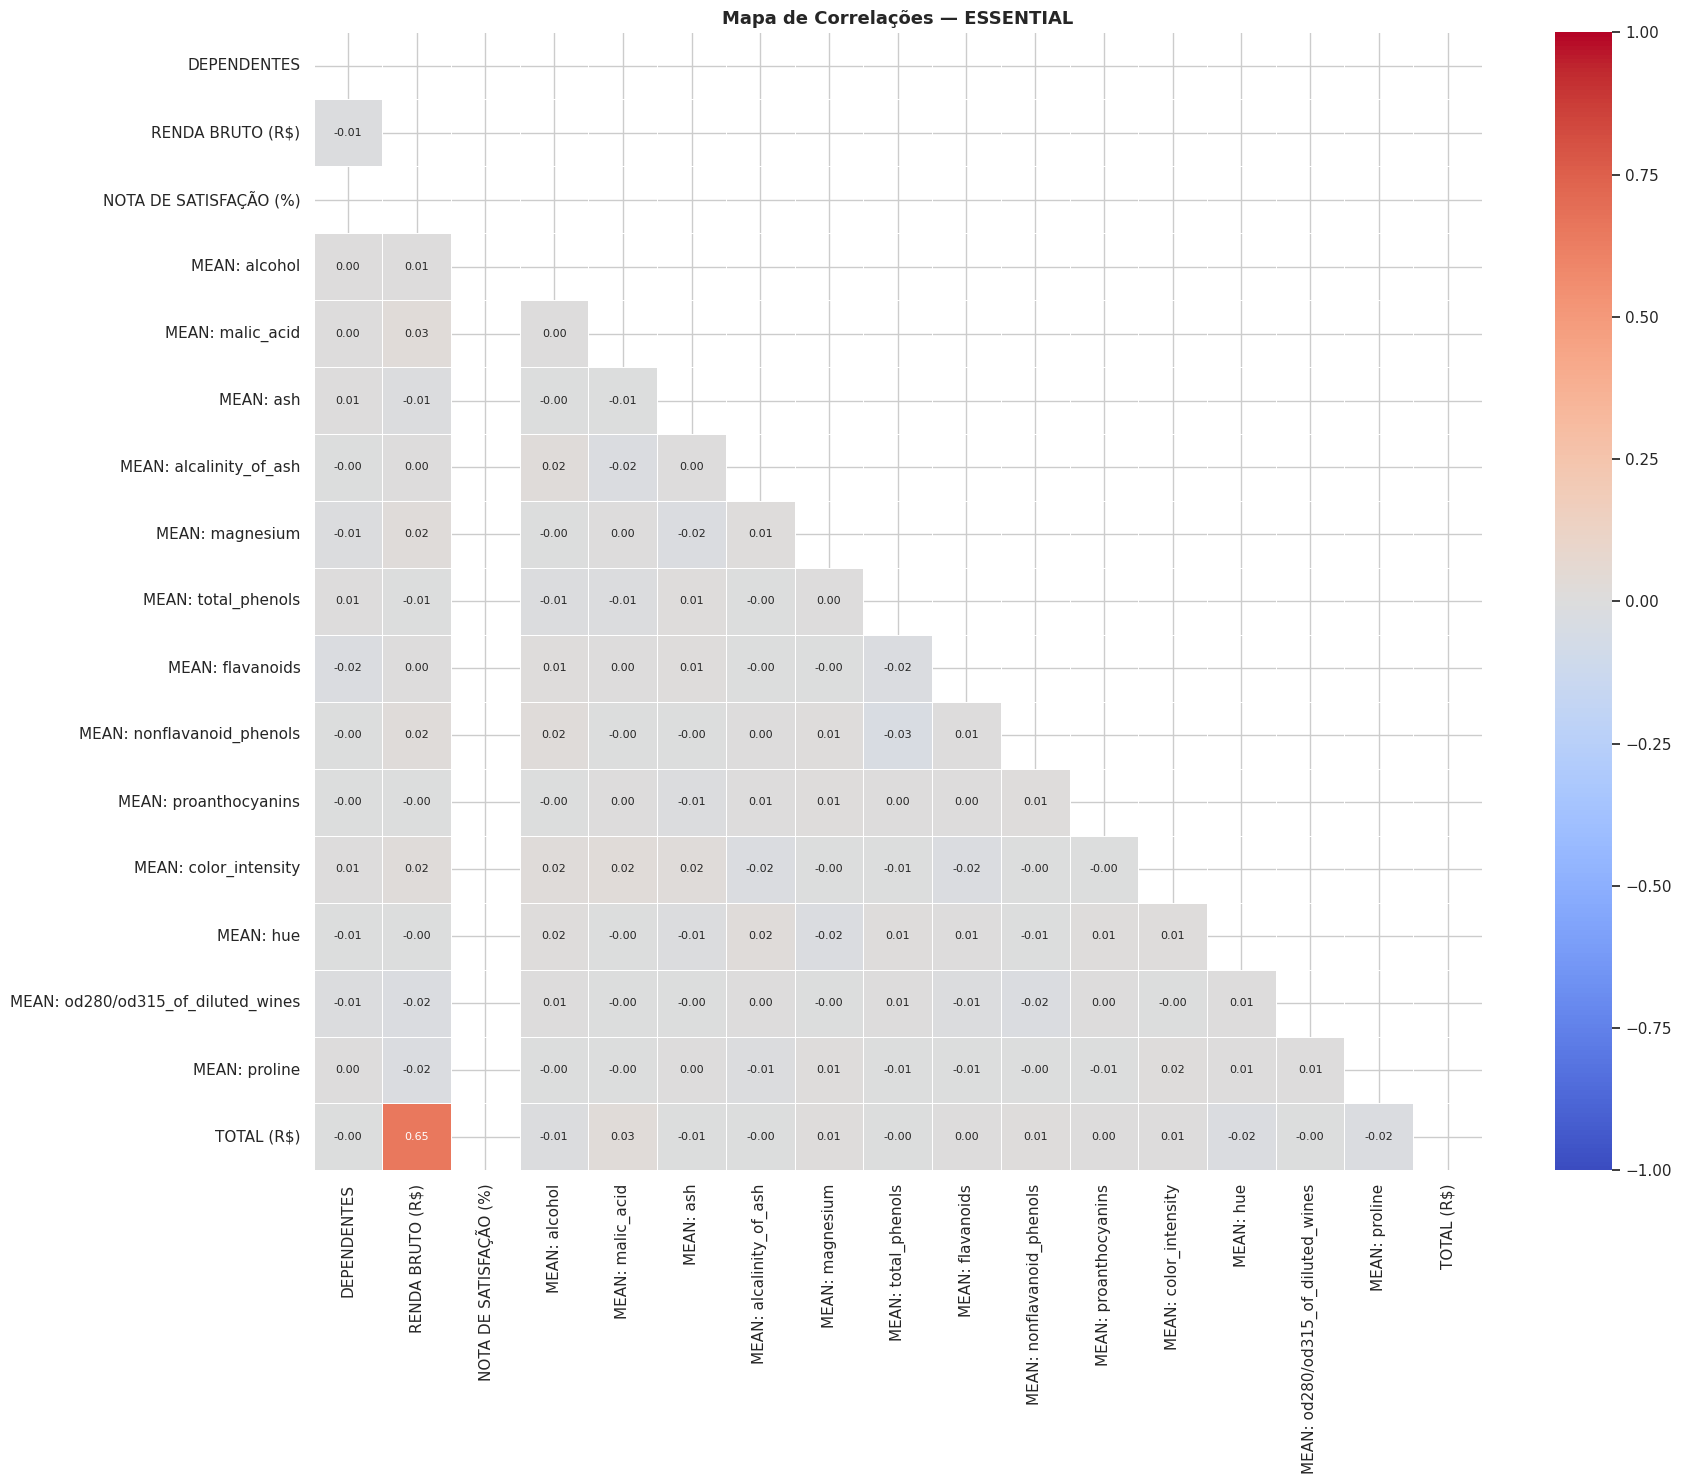


Mapa de Correlações — VIP


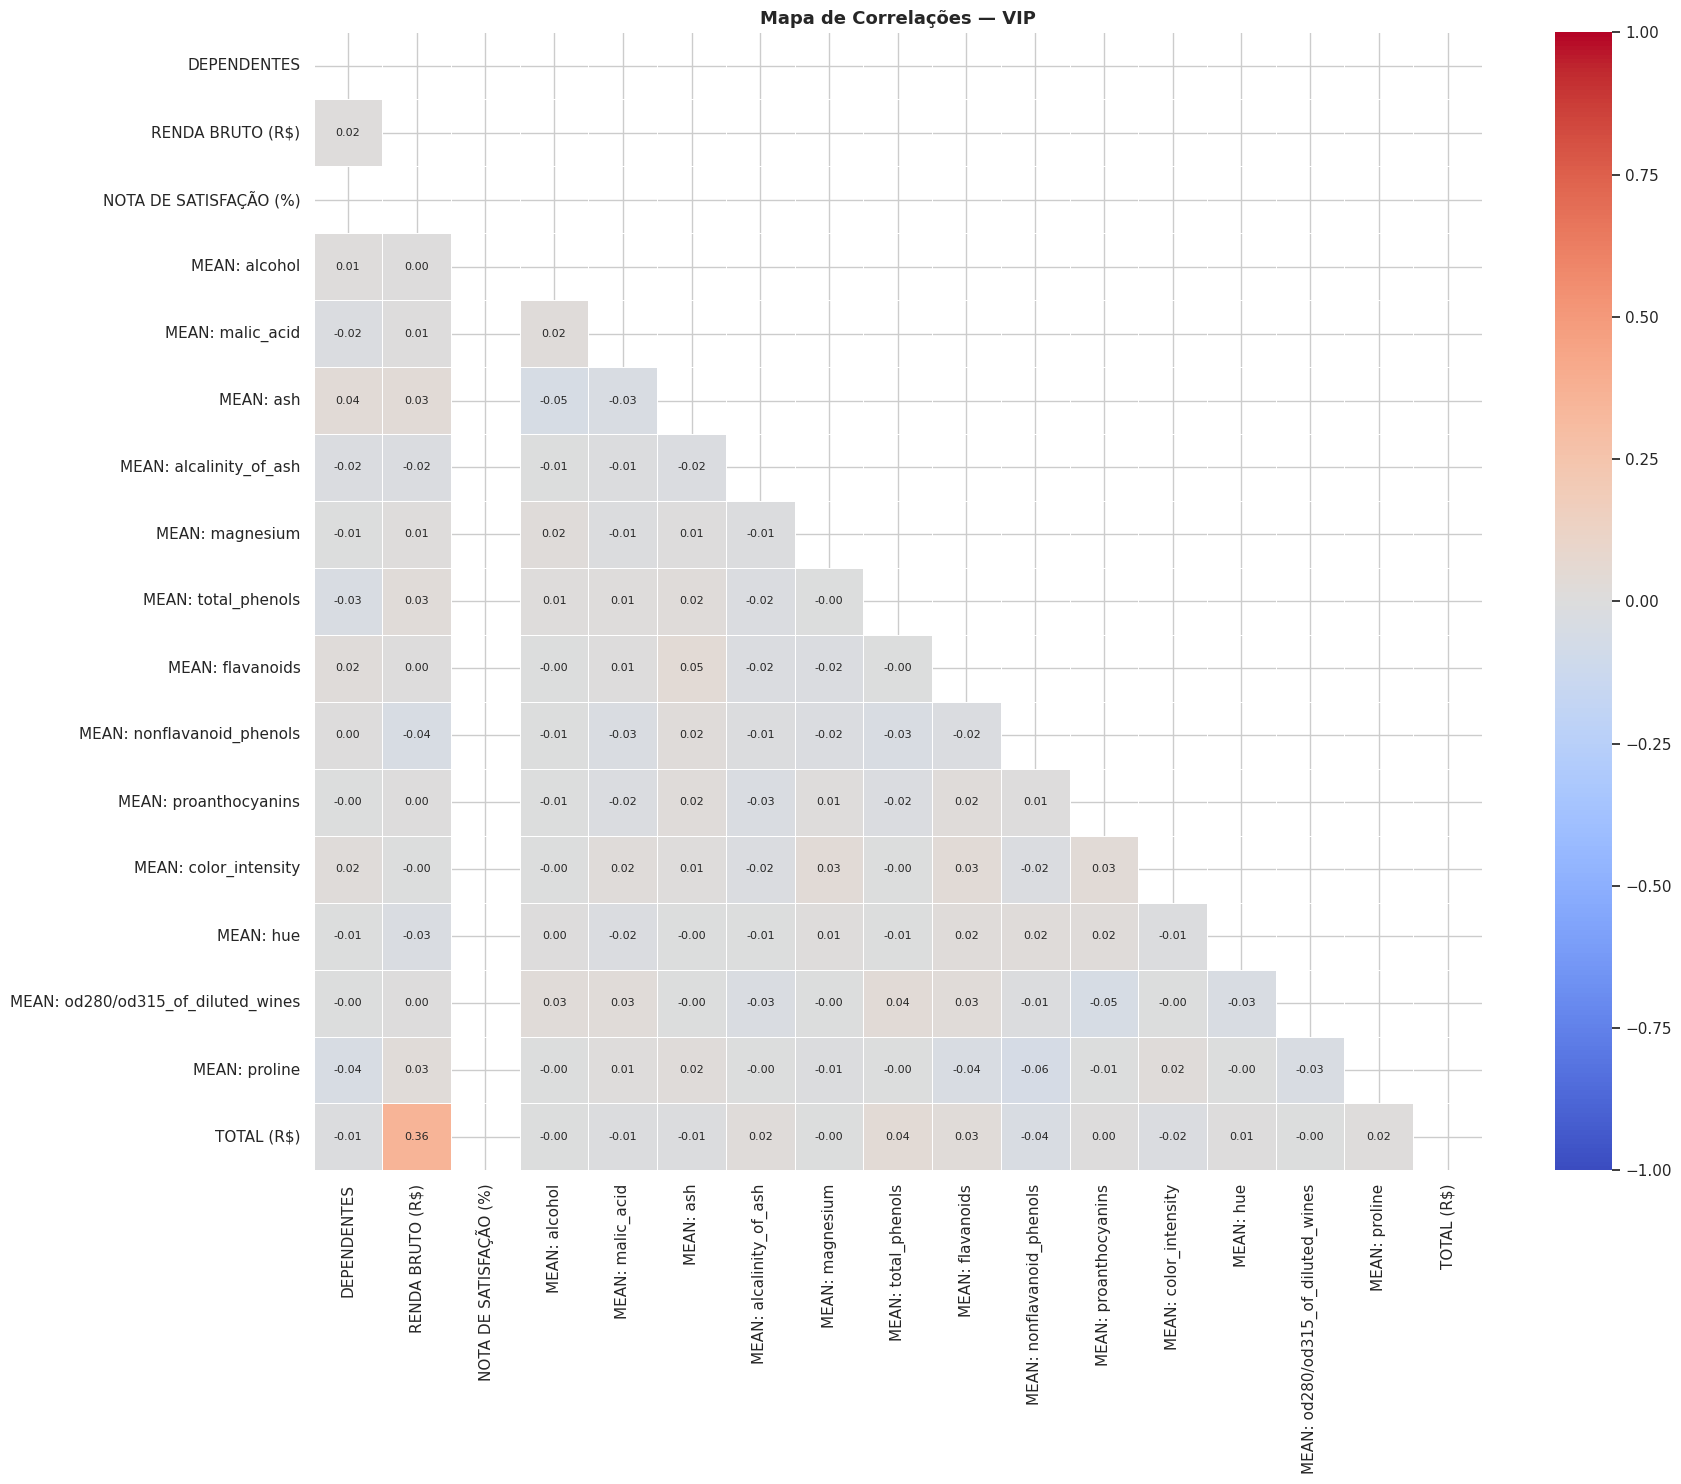


Mapa de Correlações — PRIME


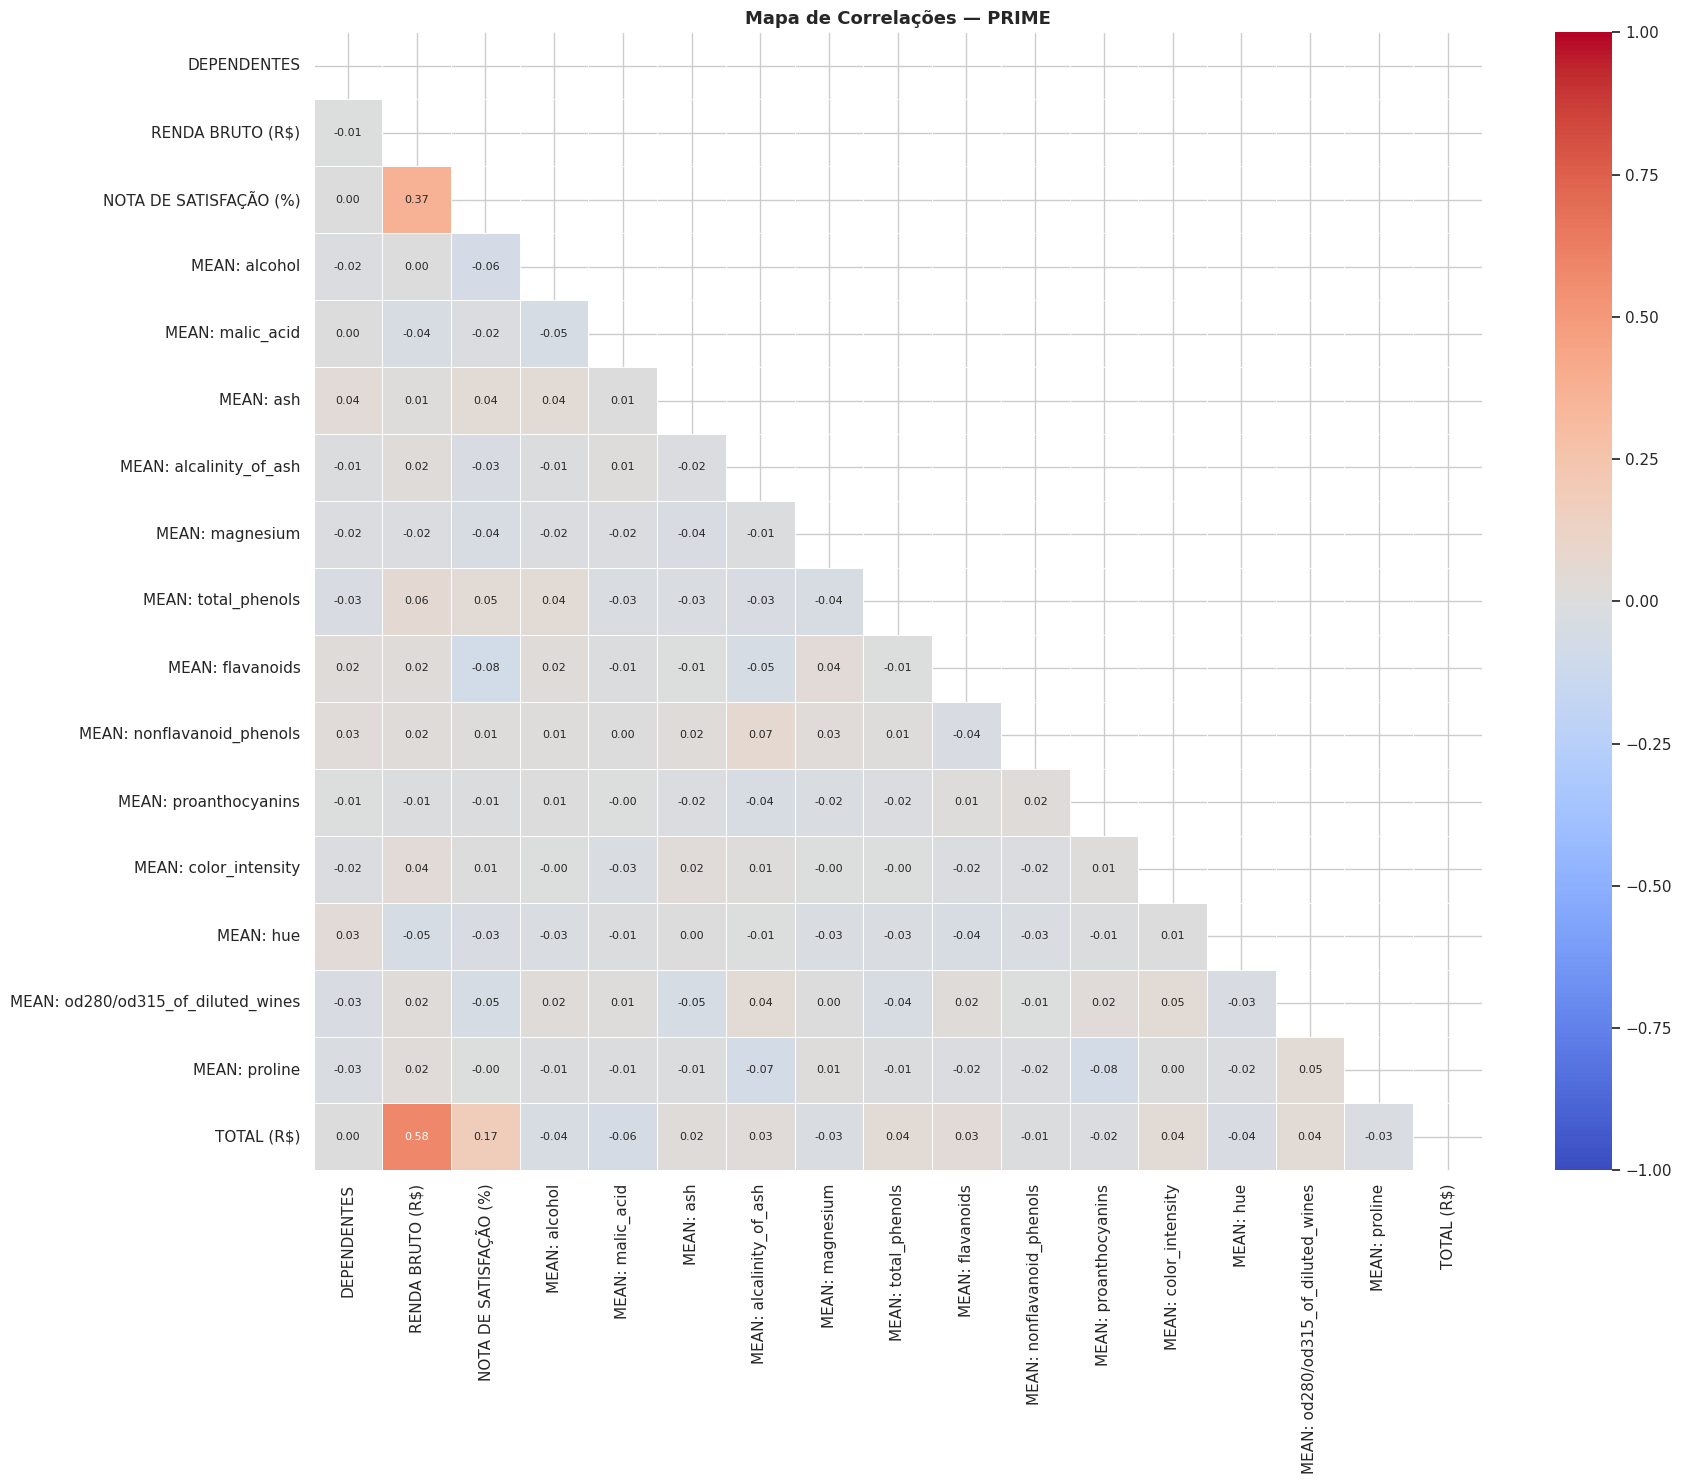

In [21]:
def Atividade3_4_2(categoria: Optional[str] = None) -> None:
    """
    Gera o mapa de calor (heatmap) das correlações entre variáveis quantitativas.
    
    Args:
        categoria: Categoria de TIPO DA CONTA ('ESSENTIAL', 'VIP', 'PRIME').
                  Se None, usa o dataset completo.
    """
    global df_amostra
    
    if categoria is not None:
        df_temp = df_amostra[df_amostra[COLUNA_CATEGORIA] == categoria].copy()
        titulo = f'Mapa de Correlações — {categoria}'
    else:
        df_temp = df_amostra.copy()
        titulo = 'Mapa de Correlações — Dataset Completo'
    
    colunas_num = COLUNAS_QUANTITATIVAS_X + [COLUNA_TARGET]
    matriz_corr = df_temp[colunas_num].corr()
    
    fig, ax = plt.subplots(figsize=(18, 15))
    
    # Máscara triângulo superior para evitar duplicidade
    mascara = np.triu(np.ones_like(matriz_corr, dtype=bool))
    
    sns.heatmap(
        matriz_corr,
        mask=mascara,
        annot=True,
        fmt='.2f',
        cmap='coolwarm',
        center=0,
        vmin=-1, vmax=1,
        linewidths=0.5,
        ax=ax,
        annot_kws={'size': 8},
    )
    
    ax.set_title(titulo, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Executar para cada categoria
print("Mapa de Correlações — ESSENTIAL")
Atividade3_4_2('ESSENTIAL')

print("\nMapa de Correlações — VIP")
Atividade3_4_2('VIP')

print("\nMapa de Correlações — PRIME")
Atividade3_4_2('PRIME')